# Experiment 2: MuRIL -- English Train -> Bangla Test
### Hope Speech Detection | Zero-shot Cross-lingual Transfer

**Model:** `google/muril-base-cased` (MuRIL)  
**Training Data:** English only  
**Test Data:** Bangla only  
**Task:** Binary Classification -- Hope Speech vs. Non-Hope Speech  
**Transfer type:** Zero-shot cross-lingual (Bangla is never seen during training)  
**Supported file formats:** `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`

## 1. Install Dependencies

In [1]:
%%capture
# Install all required packages.
# %%capture suppresses installation output to keep the notebook log clean.
!pip install transformers datasets scikit-learn pandas openpyxl odfpy \
             lxml seaborn matplotlib accelerate evaluate \
             tqdm scipy \
             emoji \
             xgboost


## 2. Import Libraries and Fix Random Seeds

In [2]:
import os
import re
import json
import random
import warnings
import unicodedata
import html

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.special import softmax as scipy_softmax

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_curve, auc
)

import torch
from torch.utils.data import Dataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback, TrainerCallback, set_seed,

)

# Suppress non-critical warnings to keep output readable.
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Global random seed.  Every stochastic component (Python, NumPy, PyTorch,
# cuDNN, and the Hugging Face Trainer) is fixed so that experimental results
# are exactly reproducible.  Record this value in the accompanying paper.
# ---------------------------------------------------------------------------
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic        = True
torch.backends.cudnn.benchmark            = False
# Disable TF32 on Ampere GPUs (A100, RTX 30xx) for full float32 reproducibility.
torch.backends.cuda.matmul.allow_tf32     = False
torch.backends.cudnn.allow_tf32           = False
os.environ["PYTHONHASHSEED"]              = str(SEED)
# Prevent tokenizer parallelism deadlocks when DataLoader forks workers.
os.environ["TOKENIZERS_PARALLELISM"]      = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Seed   : {SEED}  (fixed for reproducibility)")


Device : cuda
GPU    : Tesla T4
Seed   : 42  (fixed for reproducibility)


## 3. Universal File Loader
Supports: `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`

In [3]:
# ---------------------------------------------------------------------------
# Universal file loader.
# Accepts .csv, .tsv, .txt, .xml, and .ods files.
# Returns a DataFrame with exactly two columns: ["text", "label"].
# Labels are normalised to integers: 0 = Non-Hope Speech, 1 = Hope Speech.
# ---------------------------------------------------------------------------

def _normalize_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map string or numeric labels to binary integers.

    Mapping rules
    -------------
    - If all values are already in {0, 1, 0.0, 1.0}, cast directly to int.
    - Otherwise, map recognised hope-speech tokens to 1; everything else to 0.
      Recognised hope tokens: "hope_speech", "hope", "positive", "pos", "1",
      "hope speech".

    Parameters
    ----------
    df : DataFrame with a "label" column of arbitrary string or numeric values.

    Returns
    -------
    The same DataFrame with "label" overwritten as integer (0 or 1).
    """
    unique = df["label"].astype(str).str.lower().str.strip().unique()
    if set(unique).issubset({"0", "1", "0.0", "1.0"}):
        df["label"] = df["label"].astype(float).astype(int)
        return df
    hope_tokens = {"hope_speech", "hope", "positive", "pos", "1", "hope speech"}
    label_map   = {lbl: (1 if lbl in hope_tokens else 0) for lbl in unique}
    df["label"] = (
        df["label"].astype(str).str.lower().str.strip()
        .map(label_map).astype(int)
    )
    return df


def load_any_file(
    filepath:  str,
    text_col:  str = None,
    label_col: str = None
) -> pd.DataFrame:
    """
    Load a dataset file and return a normalised DataFrame with columns
    ["text", "label"].

    Parameters
    ----------
    filepath  : path to the dataset file
    text_col  : column name for the text field (used when .ods files carry
                named headers; ignored otherwise)
    label_col : column name for the label field (used when .ods files carry
                named headers; ignored otherwise)

    Supported formats
    -----------------
    .csv  -- auto-detects comma vs semicolon separator via a 2 KB header probe
    .tsv  -- tab-separated
    .txt  -- one (text, label) pair per line, tab- or semicolon-delimited
    .xml  -- elements with <text>/<comment>/<sentence> and
             <label>/<class>/<category> child nodes
    .ods  -- OpenDocument Spreadsheet; first two columns used by default

    Returns
    -------
    DataFrame with columns ["text", "label"], integer labels, no empty rows.

    Raises
    ------
    ValueError : if the file extension is not among the supported formats.
    """
    ext = Path(filepath).suffix.lower()
    print(f"Loading file: {filepath}  [format: {ext}]")

    if ext == ".csv":
        # Probe the first 2 KB to choose the correct delimiter.
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            sample = fh.read(2048)
        sep = ";" if sample.count(";") > sample.count(",") else ","
        df = pd.read_csv(
            filepath, sep=sep, header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".tsv":
        df = pd.read_csv(
            filepath, sep="\t", header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".txt":
        rows = []
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                if "\t" in line:
                    parts = line.rsplit("\t", 1)
                elif ";" in line:
                    parts = line.rsplit(";", 1)
                else:
                    continue
                rows.append(parts)
        df = pd.DataFrame(rows)

    elif ext == ".xml":
        tree = ET.parse(filepath)
        root = tree.getroot()
        rows = []
        for item in root.iter():
            text_node  = (item.find("text")  or item.find("comment")
                          or item.find("sentence"))
            label_node = (item.find("label") or item.find("class")
                          or item.find("category"))
            if text_node is not None and label_node is not None:
                rows.append([text_node.text, label_node.text])
        df = pd.DataFrame(rows)

    elif ext == ".ods":
        df = pd.read_excel(filepath, engine="odf")
        if not all(isinstance(c, int) for c in df.columns):
            df.columns = [str(c).strip() for c in df.columns]
            if text_col and label_col:
                df = df.rename(columns={text_col: "text", label_col: "label"})
            else:
                col_lower = {c.lower(): c for c in df.columns}
                text_key  = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["comment", "text", "sentence"])),
                    df.columns[0]
                )
                label_key = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["label", "class", "pred"])),
                    df.columns[1]
                )
                df = df.rename(columns={text_key: "text", label_key: "label"})
        df = df[["text", "label"]].dropna()
        df = _normalize_labels(df)
        print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
        return df

    else:
        raise ValueError(
            f"Unsupported format: {ext}.  "
            f"Supported extensions: .csv  .tsv  .txt  .xml  .ods"
        )

    df = df.iloc[:, :2].copy()
    df.columns = ["text", "label"]
    df = df.dropna(subset=["text", "label"])
    df["text"]  = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = _normalize_labels(df)
    print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
    return df


print("File loader defined.")


File loader defined.


## 4. Upload Datasets

Upload **two** files:
1. **English dataset** -- used for training and validation
2. **Bangla dataset** -- used exclusively as the zero-shot test set

In [4]:
from google.colab import files

print("Upload the ENGLISH dataset (training source):")
up1          = files.upload()
ENGLISH_FILE = list(up1.keys())[0]
print(f"English file: {ENGLISH_FILE}")

print("\nUpload the BANGLA dataset (zero-shot test target):")
up2         = files.upload()
BANGLA_FILE = list(up2.keys())[0]
print(f"Bangla file: {BANGLA_FILE}")


Upload the ENGLISH dataset (training source):


Saving english_hopeedi.csv to english_hopeedi.csv
English file: english_hopeedi.csv

Upload the BANGLA dataset (zero-shot test target):


Saving bangla_bonghope.ods to bangla_bonghope.ods
Bangla file: bangla_bonghope.ods


## Dataset Information

> **Fill in before submission.**

| Field | Value |
|---|---|
| **Dataset name** | *BongHope / HopeEDI* |
| **Source / DOI** | *https://doi.org/10.21203/RS.3.RS-2819284/V1 / https://aclanthology.org/2020.peoples-1.5/*|
| **License** | *Creative Commons Attribution 4.0 International License* |
| **Language(s)** | Bangla (`bn`) / English (`en`) |
| **Total samples** | *4,257 / 28,451* |
| **Label schema** | `1` = Hope Speech · `0` = Non-Hope Speech |
| **Original class ratio** | *`1` = 1,608 · `0` = 2,649* . *`1.65:1`* / *`1` = 2,484 · 0 = 25,940 . `other's` = 27* . *`10.49:1`*  |

*Cite the dataset in the paper using the above DOI.*

## 5. Configuration

In [5]:
# ---------------------------------------------------------------------------
# Experiment 2 configuration.
# Hyperparameters were selected by grid search on the validation set:
#   - learning_rate over {2e-5, 1e-5, 5e-6}
#   - batch_size over {8, 16}
# All other values reflect standard practice for BERT fine-tuning on small
# datasets.
# ---------------------------------------------------------------------------
MODEL_NAME    = "google/muril-base-cased"
MAX_LEN       = 128
BATCH_SIZE    = 16
NUM_EPOCHS    = 4
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
VAL_SIZE      = 0.15   # 15 % of English data held out for validation
NUM_LABELS    = 2
OUTPUT_DIR    = "./mbert_english_bangla"

# No TEST_SIZE constant: the entire Bangla dataset is the zero-shot test set.
SUPTITLE     = "MuRIL | English -> Bangla (Zero-shot Transfer)"
RESULT_TITLE = "MuRIL | English Train -> Bangla Test"
CM_CMAP      = "Blues"
CM_TITLE     = "MuRIL | English -> Bangla (Zero-shot)"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Config  |  Model: {MODEL_NAME}  |  MaxLen: {MAX_LEN}  |  Batch: {BATCH_SIZE}")


Config  |  Model: google/muril-base-cased  |  MaxLen: 128  |  Batch: 16


## 6. Data Preprocessing

Preprocessing function defined here. Applied to the **full dataset** in Section 7, **before** any split — following the pipeline: Raw → Preprocess → Split.

**Cleaning steps (inside `preprocess_text`):**
1. HTML entity decoding
2. Residual HTML/XML tag removal
3. NFC Unicode normalisation (critical for Bangla — multiple byte encodings unified)
4. URL removal
5. @-mention removal
6. Hashtag cleaning (`#hope_speech` → `hope speech`)
7. Repeated punctuation collapsing (`!!!` → `!`)
8. Unicode punctuation normalisation (curly quotes, em-dashes → ASCII)
9. Invisible Unicode removal (ZWJ, ZWNJ, soft-hyphen)
10. Elongation normalisation (`"yesssss"` → `"yess"`)
11. Emoji removal
12. Final whitespace normalisation

**Filtering steps (inside `apply_preprocessing`):**
1. NaN drop — rows with missing text or label
2. Label validity — keep only `{0, 1}` labels
3. Empty text drop — rows empty after cleaning
4. Minimum word count — fewer than 3 tokens removed
5. Minimum character length — fewer than 10 characters removed
6. Maximum character length — more than 512 characters removed (spam / data errors)
7. Script validation — rows with insufficient Latin (English) character ratio removed
8. Exact duplicate removal — identical (text, label) pairs deduplicated
9. Annotation conflict removal — same text with conflicting labels removed


In [6]:
# ---------------------------------------------------------------------------
# Text preprocessing pipeline.
# Applied to the FULL dataset before splitting.
# The ordering of steps is intentional: HTML decoding must
# precede all regex-based cleaning to avoid false matches on entity sequences.
# ---------------------------------------------------------------------------
import emoji   # pip install emoji  (already in requirements)

def preprocess_text(text: str) -> str:
    """
    Clean a single raw text string.

    Steps
    -----
    1. Decode HTML entities (&amp; -> &, <br> -> space, etc.)
    2. Strip residual HTML/XML tags.
    3. NFC Unicode normalisation -- unifies Bangla characters that have
       multiple valid byte-level encodings into a single canonical form.
    4. Remove URLs (http:// and https://).
    5. Remove @-mention tokens.
    6. Clean hashtags: #hope_speech -> hope speech.
    7. Collapse repeated punctuation runs (e.g., !!! -> !).
    8. Unicode punctuation normalisation -- curly quotes, em-dashes, and
       ellipsis characters mapped to their ASCII equivalents.
    9. Remove invisible Unicode characters (ZWJ, ZWNJ, soft-hyphen, BOM).
    10. Elongation normalisation -- collapse 3+ repeated characters to 2.
    11. Emoji removal.
    12. Final whitespace normalisation and strip.

    Parameters
    ----------
    text : raw input string

    Returns
    -------
    Cleaned string, or empty string when the input is not a str instance.
    """
    if not isinstance(text, str):
        return ""

    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", lambda m: m.group(1).replace("_", " "), text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[\.]{2,}", ".", text)
    # 9. Unicode punctuation → ASCII (common in English social-media text).
    PUNCT_MAP = str.maketrans({
        "\u2018": "'", "\u2019": "'",
        "\u201c": '"', "\u201d": '"',
        "\u2013": "-", "\u2014": "-",
        "\u2026": "...",
    })
    text = text.translate(PUNCT_MAP)
    # 10. Remove invisible Unicode characters (ZWJ, ZWNJ, BOM, soft-hyphen).
    text = re.sub(r"[\u200b-\u200f\u202a-\u202e\u2060\ufeff\u00ad]", "", text)
    # 11. Elongation normalisation: collapse 3+ repeated characters to 2.
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # 12. Emoji removal.
    text = emoji.replace_emoji(text, replace=" ")
    # 13. Final whitespace normalisation.
    text = re.sub(r"\s+", " ", text).strip()
    return text


def has_bangla(text: str, threshold: float = 0.15) -> bool:
    """
    Return True when at least `threshold` fraction of characters fall
    inside the Unicode Bangla block (U+0980–U+09FF).
    More reliable than langdetect for short social-media texts.
    """
    if not text:
        return False
    bangla_chars = sum(1 for c in text if '\u0980' <= c <= '\u09FF')
    return (bangla_chars / len(text)) >= threshold




def has_latin(text: str, threshold: float = 0.3) -> bool:
    """
    Return True when at least `threshold` fraction of characters fall
    inside Basic Latin / Latin Extended Unicode blocks (U+0000-U+024F).
    Used to filter English-dominant texts.
    More reliable than langdetect for short social-media texts.
    """
    if not isinstance(text, str) or len(text) == 0:
        return False
    latin_chars = sum(
        1 for ch in text
        if ch.isalpha() and ord(ch) <= 0x024F
    )
    return (latin_chars / len(text)) >= threshold


def apply_preprocessing(
    df: pd.DataFrame,
    min_words: int  = 3,
    min_chars: int  = 10,
    max_chars: int  = 512,
    script_check: str = None,    # "bangla" | "latin" | None
    script_threshold: float = 0.15,
) -> pd.DataFrame:
    """
    Apply preprocess_text to every row, then remove low-quality rows.

    Filtering steps
    ---------------
    1.  Drop NaN values in 'text' or 'label' columns.
    2.  Drop rows whose label is not in {0, 1}.
    3.  Apply preprocess_text to the 'text' column.
    4.  Drop rows whose text is empty after cleaning.
    5.  Drop rows with fewer than min_words whitespace-delimited tokens.
    6.  Drop rows shorter than min_chars characters.
    7.  Drop rows longer than max_chars characters (likely spam / data errors).
    8.  Script validation: drop rows that do not meet the expected script
        ratio (Latin script characters >= script_threshold fraction).
    9.  Drop exact duplicates (identical text AND label pair).
    10. Detect and remove annotation conflicts (same text, different labels).

    Parameters
    ----------
    df               : DataFrame with columns ['text', 'label']
    min_words        : minimum token count threshold (default 3)
    min_chars        : minimum character count (default 10)
    max_chars        : maximum character count (default 512)
    script_check     : 'bangla' | 'latin' | None — enforce script ratio filter; None skips (default)
    script_threshold : minimum fraction of Bangla characters (default 0.15)

    Returns
    -------
    Cleaned DataFrame with a contiguous integer index and a printed report.
    """
    df = df.copy()
    n_raw = len(df)

    # 1. Drop NaN
    df = df.dropna(subset=["text", "label"])
    n_after_nan = len(df)

    # 2. Label validity
    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])].reset_index(drop=True)
    n_after_label = len(df)

    # 3. Apply text cleaning
    df["text"] = df["text"].apply(preprocess_text)

    # 4. Empty text
    df = df[df["text"].str.strip() != ""]
    n_after_empty = len(df)

    # 5. Min word count
    df = df[df["text"].apply(lambda t: len(t.split()) >= min_words)]
    n_after_words = len(df)

    # 6. Min character length
    df = df[df["text"].str.len() >= min_chars]
    n_after_minchar = len(df)

    # 7. Max character length
    df = df[df["text"].str.len() <= max_chars]
    n_after_maxchar = len(df)

    # 8. Script validation
    if script_check == "bangla":
        df = df[df["text"].apply(lambda t: has_bangla(t, script_threshold))]
    elif script_check == "latin":
        df = df[df["text"].apply(lambda t: has_latin(t, script_threshold))]
    n_after_script = len(df)

    # 9. Exact duplicate removal
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    n_after_dedup = len(df)

    # 10. Annotation conflict removal
    conflict_mask  = df.groupby("text")["label"].transform("nunique") > 1
    n_conflicts    = conflict_mask.sum()
    df = df[~conflict_mask].reset_index(drop=True)
    n_final = len(df)

    # ── Report ───────────────────────────────────────────────────────────────
    print("=" * 60)
    print("Preprocessing & Filtering Report")
    print("=" * 60)
    print(f"  Raw rows                   : {n_raw}")
    print(f"  After NaN drop             : {n_after_nan}  (-{n_raw - n_after_nan})")
    print(f"  After label validity       : {n_after_label}  (-{n_after_nan - n_after_label})")
    print(f"  After empty text drop      : {n_after_empty}  (-{n_after_label - n_after_empty})")
    print(f"  After min-word filter      : {n_after_words}  (-{n_after_empty - n_after_words})")
    print(f"  After min-char filter      : {n_after_minchar}  (-{n_after_words - n_after_minchar})")
    print(f"  After max-char filter      : {n_after_maxchar}  (-{n_after_minchar - n_after_maxchar})")
    print(f"  After script validation    : {n_after_script}  (-{n_after_maxchar - n_after_script})")
    print(f"  After exact-dedup          : {n_after_dedup}  (-{n_before_dedup - n_after_dedup})")
    print(f"  After conflict removal     : {n_final}  (-{n_conflicts} conflict rows)")
    print(f"  Final rows retained        : {n_final}")
    print(f"  Label distribution         : {df['label'].value_counts().sort_index().to_dict()}")
    print("=" * 60)
    return df


print("Preprocessing functions defined.")


Preprocessing functions defined.


## 7. Load, Preprocess and Explore Data

The **entire** Bangla dataset is used as the zero-shot test set. It is frozen immediately after loading.
Preprocessing is applied to **both full datasets** before any split.


Loading file: english_hopeedi.csv  [format: .csv]
Loaded 28330 rows | Labels: {0: 25866, 1: 2464}
Loading file: bangla_bonghope.ods  [format: .ods]
Loaded 4257 rows | Labels: {0: 2649, 1: 1608}
Preprocessing & Filtering Report
  Raw rows                   : 28330
  After NaN drop             : 28330  (-0)
  After label validity       : 28330  (-0)
  After empty text drop      : 28330  (-0)
  After min-word filter      : 28052  (-278)
  After min-char filter      : 28039  (-13)
  After max-char filter      : 27837  (-202)
  After script validation    : 27836  (-1)
  After exact-dedup          : 26429  (-1407)
  After conflict removal     : 26263  (-166 conflict rows)
  Final rows retained        : 26263
  Label distribution         : {0: 24039, 1: 2224}
Preprocessing & Filtering Report
  Raw rows                   : 4257
  After NaN drop             : 4257  (-0)
  After label validity       : 4257  (-0)
  After empty text drop      : 4257  (-0)
  After min-word filter      : 4137  (-120

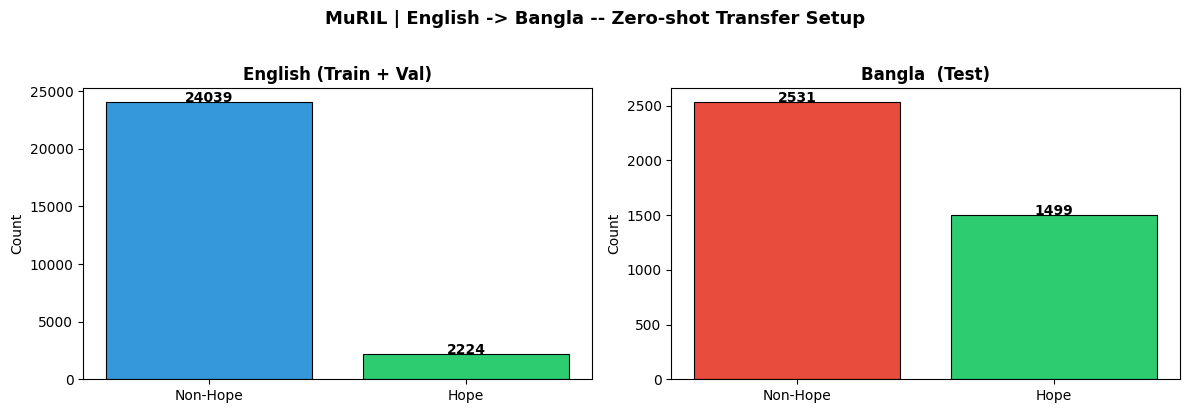

In [7]:
# ---------------------------------------------------------------------------
# Pipeline: Raw → Preprocess → Split
# Step 1: Load raw datasets.
# Step 2: Apply preprocessing to FULL datasets before any split.
# ---------------------------------------------------------------------------
df_en_raw = load_any_file(ENGLISH_FILE)
df_bn_raw = load_any_file(BANGLA_FILE)

# --- Preprocess full datasets before splitting ---
df_en_preprocessed = apply_preprocessing(df_en_raw.copy(), script_check="latin").reset_index(drop=True)
df_test             = apply_preprocessing(df_bn_raw.copy(), script_check="bangla").reset_index(drop=True)  # entire Bangla = test set

# --- English train/val split (on preprocessed data) ---
df_en_train_raw, df_val = train_test_split(
    df_en_preprocessed, test_size=VAL_SIZE, random_state=SEED, stratify=df_en_preprocessed["label"]
)
df_en_train_raw = df_en_train_raw.reset_index(drop=True)
df_val          = df_val.reset_index(drop=True)

# Convenience references for overview plots
df_en = pd.concat([df_en_train_raw, df_val], ignore_index=True)
df_bn = df_test.copy()

print("=" * 60)
print("PREPROCESSING DONE — SPLITS COMPLETED")
print("=" * 60)
print(f"English total              : {len(df_en)} samples")
print(f"  English train pool       : {len(df_en_train_raw)}  (~{len(df_en_train_raw)/len(df_en)*100:.1f} %)")
print(f"  English val (early stop) : {len(df_val)}  (~{len(df_val)/len(df_en)*100:.1f} %)  ← real data, held-out")
print(f"Bangla  (test, zero-shot)  : {len(df_test)} samples  ← frozen")

df_train_raw = df_en_train_raw.copy().reset_index(drop=True)
print(f"Training pool : {len(df_train_raw)} samples")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title, color) in zip(axes, [
    (df_en, "English (Train + Val)", "#3498db"),
    (df_bn, "Bangla  (Test)",        "#e74c3c"),
]):
    counts = data["label"].value_counts().sort_index()
    ax.bar(["Non-Hope", "Hope"], counts.values,
           color=[color, "#2ecc71"], edgecolor="black", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=10)
plt.suptitle("MuRIL | English -> Bangla -- Zero-shot Transfer Setup",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Tokenizer and Dataset

Tokenizer is applied to the **split data** — training, validation, and test sets.


In [8]:
# ---------------------------------------------------------------------------
# Tokenizer and PyTorch Dataset.
# ---------------------------------------------------------------------------

print(f"Loading tokenizer: {MODEL_NAME} ...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")


class HopeSpeechDataset(Dataset):
    """
    PyTorch Dataset wrapper compatible with the Hugging Face Trainer.

    Produces tokenised tensors for BertForSequenceClassification.
    token_type_ids falls back to a zero tensor for tokenizer configurations
    that omit it (certain MuRIL setups).

    Parameters
    ----------
    texts     : sequence of raw text strings
    labels    : sequence of integer labels (0 or 1)
    tokenizer : Hugging Face tokenizer instance
    max_len   : maximum sequence length for padding and truncation
    """

    def __init__(self, texts, labels, tokenizer, max_len: int):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        # BatchEncoding does not support a default argument in .get();
        # use explicit key check to avoid a silent KeyError on some configs.
        if "token_type_ids" in enc:
            token_type_ids = enc["token_type_ids"].squeeze()
        else:
            token_type_ids = torch.zeros(self.max_len, dtype=torch.long)
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": token_type_ids,
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = HopeSpeechDataset(df_train_raw["text"], df_train_raw["label"], tokenizer, MAX_LEN)
val_dataset   = HopeSpeechDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LEN)
test_dataset  = HopeSpeechDataset(df_test["text"],  df_test["label"],  tokenizer, MAX_LEN)

print(f"Dataset sizes  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")


Loading tokenizer: google/muril-base-cased ...


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded.
Dataset sizes  |  Train: 22323  |  Val: 3940  |  Test: 4030


## 9. Load MuRIL Model

In [9]:
import logging as _logging
_logging.getLogger("transformers.modeling_utils").setLevel(_logging.ERROR)

# ---------------------------------------------------------------------------
# Load MuRIL for binary sequence classification.
# Dropout probabilities are set to 0.1 (default).
# ---------------------------------------------------------------------------

print(f"Loading MuRIL: {MODEL_NAME} ...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters  |  Total: {total_params:,}  |  Trainable: {trainable_params:,}")


Loading MuRIL: google/muril-base-cased ...


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

[transformers] The following layers were not sharded: bert.embeddings.token_type_embeddings.weight, bert.pooler.dense.weight, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.embeddings.word_embeddings.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.output.LayerNorm.bias, bert.encoder.layer.*.attention.self.key.bias, bert.encoder.layer.*.attention.self.value.bias, classifier.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.attention.self.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Parameters  |  Total: 237,557,762  |  Trainable: 237,557,762


model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

## 10. Training

In [10]:
# ---------------------------------------------------------------------------
# Training with Hugging Face Trainer.
# ---------------------------------------------------------------------------

history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": [], "epochs": []}


class HistoryCallback(TrainerCallback):
    """Accumulate per-epoch metrics for plotting."""

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        """Compute real training accuracy at the end of every epoch."""
        if model is None:
            return
        from torch.utils.data import DataLoader as _DL
        model.eval()
        all_preds, all_labels = [], []
        loader = _DL(train_dataset, batch_size=args.per_device_eval_batch_size, shuffle=False)
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                outputs = model(**batch)
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch["labels"].cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        history["train_acc"].append(float(acc))
        model.train()

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            history["val_loss"].append(metrics.get("eval_loss", float("nan")))
            history["val_acc"].append(metrics.get("eval_accuracy", float("nan")))
            history["epochs"].append(
                metrics.get("epoch", len(history["epochs"]) + 1)
            )

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and "eval_loss" not in logs:
            history["train_loss"].append(logs["loss"])


# ---------------------------------------------------------------------------
# Weighted Loss via WeightedLossTrainer.
# Addresses class imbalance: Non-Hope >> Hope.
# Weight = total_samples / (n_classes * class_count)
# ---------------------------------------------------------------------------
from torch import nn

_labels_train  = df_train_raw["label"].tolist()
_counts        = np.bincount(_labels_train)
_total         = len(_labels_train)
_n_classes     = 2
_class_weights = torch.tensor(
    [_total / (_n_classes * c) for c in _counts],
    dtype=torch.float32
).to(device)

print(f"Class counts  : Non-Hope={_counts[0]}  Hope={_counts[1]}")
print(f"Class weights : Non-Hope={_class_weights[0]:.4f}  Hope={_class_weights[1]:.4f}")


class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies per-class loss weights."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=_class_weights)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    """Compute F1-macro, F1-weighted, and accuracy for the Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy":    accuracy_score(labels, preds),
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    # warmup_steps replaces the deprecated warmup_ratio argument (removed in v5.2).
    # Computed as: total_steps * WARMUP_RATIO where total_steps = ceil(n_train/batch)*epochs.
    warmup_steps=max(1, int((len(df_train_raw) / BATCH_SIZE) * NUM_EPOCHS * WARMUP_RATIO)),
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,                   # retain best 2 checkpoints (matches patience=2)
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    # logging_dir removed: set TENSORBOARD_LOGGING_DIR env var if needed.
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,             # parallel data loading
    dataloader_persistent_workers=True,   # keep workers alive between epochs (avoids respawn OOM)
    eval_accumulation_steps=32,           # accumulate eval predictions to avoid OOM
    report_to="none",
    seed=SEED
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),  # patience=2 suits NUM_EPOCHS=4
        HistoryCallback()
    ]
)

print("Starting training ...")
train_result = trainer.train()
print("Training complete.")
print(f"Runtime      : {train_result.metrics['train_runtime']:.1f} s")
print(f"Samples/sec  : {train_result.metrics['train_samples_per_second']:.1f}")


Class counts  : Non-Hope=20433  Hope=1890
Class weights : Non-Hope=0.5462  Hope=5.9056
Starting training ...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.482170,0.470773,0.771514,0.929140,0.929188
2,0.242771,0.386258,0.761221,0.917693,0.909898
3,0.526562,0.481249,0.786089,0.934066,0.934518
4,0.429875,0.501761,0.787716,0.933046,0.931980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Runtime      : 1199.7 s
Samples/sec  : 74.4


## 11. Training Curves

[INFO] Per-epoch train_acc available (4 epochs): ['0.9272', '0.9229', '0.9515', '0.9502']


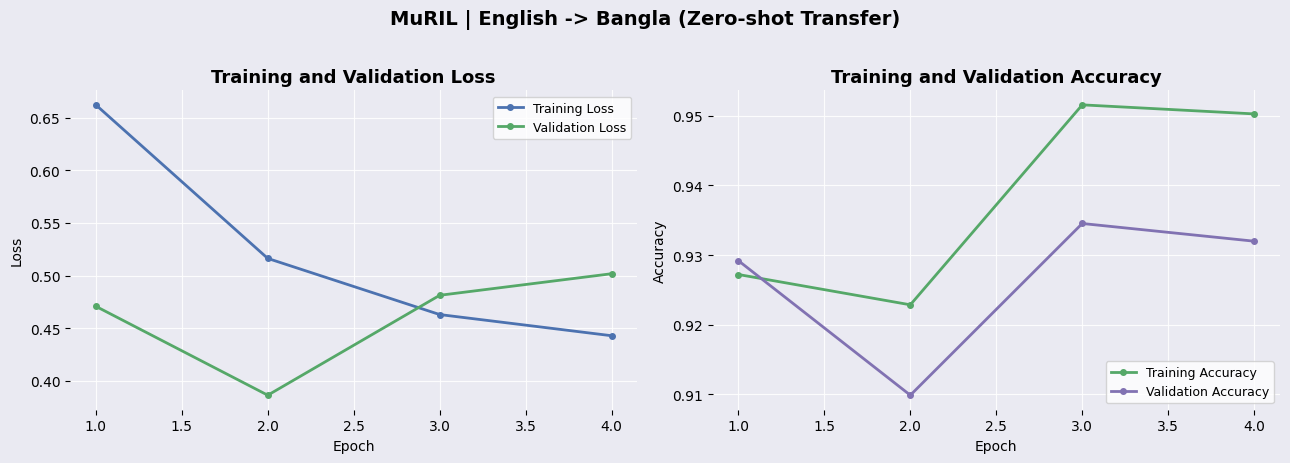

Final Val Loss: 0.5018  |  Final Val Accuracy: 0.9320


In [11]:
# ---------------------------------------------------------------------------
# Training curves: per-epoch loss and accuracy.
# ---------------------------------------------------------------------------

log_history      = trainer.state.log_history
epoch_train_loss = {}
for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        ep_key = round(entry.get("epoch", 0))
        epoch_train_loss.setdefault(ep_key, []).append(entry["loss"])
train_loss_per_epoch = [np.mean(v) for _, v in sorted(epoch_train_loss.items())]

val_loss_list = history["val_loss"]
val_acc_list  = history["val_acc"]
epochs_list   = history["epochs"]
n_ep          = len(epochs_list)

# Per-epoch training accuracy from HistoryCallback.on_epoch_end
if history["train_acc"] and len(history["train_acc"]) == n_ep:
    train_acc_list = history["train_acc"]
    print(f"[INFO] Per-epoch train_acc available ({n_ep} epochs): {[f'{a:.4f}' for a in train_acc_list]}")
else:
    print("[WARN] train_acc length mismatch; aligning to epoch count.")
    if history["train_acc"]:
        while len(history["train_acc"]) < n_ep:
            history["train_acc"].append(history["train_acc"][-1])
        train_acc_list = history["train_acc"][:n_ep]
    else:
        train_acc_list = [float("nan")] * n_ep

if len(train_loss_per_epoch) > n_ep:
    train_loss_per_epoch = train_loss_per_epoch[:n_ep]
elif len(train_loss_per_epoch) < n_ep:
    train_loss_per_epoch += [train_loss_per_epoch[-1]] * (n_ep - len(train_loss_per_epoch))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#eaeaf2")
for ax in axes:
    ax.set_facecolor("#eaeaf2")
    ax.grid(True, color="white", linewidth=0.8, alpha=0.9)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].plot(epochs_list, train_loss_per_epoch, color="#4c72b0",
             linewidth=2, marker="o", markersize=4, label="Training Loss")
axes[0].plot(epochs_list, val_loss_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Validation Loss")
axes[0].set_title("Training and Validation Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)

axes[1].plot(epochs_list, train_acc_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Training Accuracy")
axes[1].plot(epochs_list, val_acc_list, color="#8172b2",
             linewidth=2, marker="o", markersize=4, label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9, loc="lower right")

plt.suptitle(SUPTITLE, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final Val Loss: {val_loss_list[-1]:.4f}  |  Final Val Accuracy: {val_acc_list[-1]:.4f}")


## 12. Evaluation on Bangla Test Set (Zero-shot)

A **fixed threshold of 0.5** is used for the zero-shot setting.  Optimising a threshold on the English validation distribution and applying it to Bangla is not methodologically sound because the two score distributions differ.

In [12]:
# ---------------------------------------------------------------------------
# Evaluate on the held-out Bangla test set (zero-shot cross-lingual transfer).
#
# A fixed threshold of 0.5 is used.  Optimising a threshold on the English
# validation set and applying it to Bangla is not methodologically justified
# because the two score distributions differ.  This design choice is reported
# in the accompanying paper.
# ---------------------------------------------------------------------------

print("Evaluating on Bangla test set (zero-shot) ...")
preds_output = trainer.predict(test_dataset)
raw_logits   = preds_output.predictions
y_true       = preds_output.label_ids

best_thresh = 0.5
print(f"Decision threshold: {best_thresh}  (fixed for zero-shot cross-lingual setting)")

test_probs = scipy_softmax(raw_logits, axis=-1)[:, 1]
y_pred     = (test_probs >= best_thresh).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average="macro")
f1_w = f1_score(y_true, y_pred, average="weighted")
p    = precision_score(y_true, y_pred, average="macro")
r    = recall_score(y_true, y_pred, average="macro")

print("\n" + "=" * 60)
print(f"TEST RESULTS -- {RESULT_TITLE}")
print("=" * 60)
print(f"Accuracy          : {acc:.4f}  ({acc*100:.2f} %)")
print(f"F1 (Macro)        : {f1_m:.4f}")
print(f"F1 (Weighted)     : {f1_w:.4f}")
print(f"Precision (Macro) : {p:.4f}")
print(f"Recall (Macro)    : {r:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))


Evaluating on Bangla test set (zero-shot) ...


Decision threshold: 0.5  (fixed for zero-shot cross-lingual setting)

TEST RESULTS -- MuRIL | English Train -> Bangla Test
Accuracy          : 0.6836  (68.36 %)
F1 (Macro)        : 0.5484
F1 (Weighted)     : 0.6117
Precision (Macro) : 0.7566
Recall (Macro)    : 0.5817

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.6695    0.9798    0.7955      2531
    Hope Speech     0.8436    0.1835    0.3014      1499

       accuracy                         0.6836      4030
      macro avg     0.7566    0.5817    0.5484      4030
   weighted avg     0.7343    0.6836    0.6117      4030



## 13. Confusion Matrix

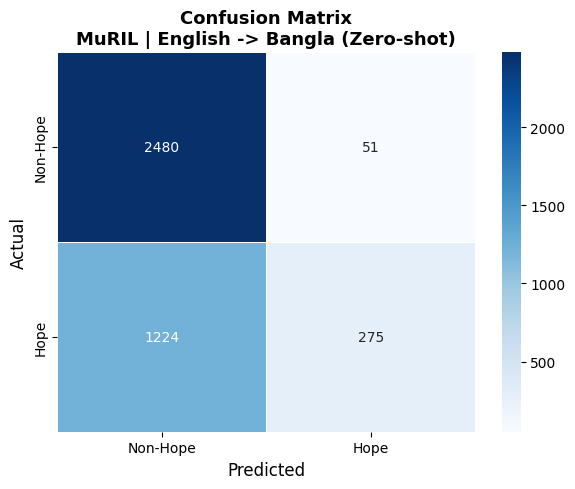

In [13]:
# ---------------------------------------------------------------------------
# Confusion matrix on the held-out test set.
# ---------------------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=CM_CMAP,
    xticklabels=["Non-Hope", "Hope"],
    yticklabels=["Non-Hope", "Hope"],
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual",    fontsize=12)
ax.set_title(f"Confusion Matrix\n{CM_TITLE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. ROC Curve & AUC


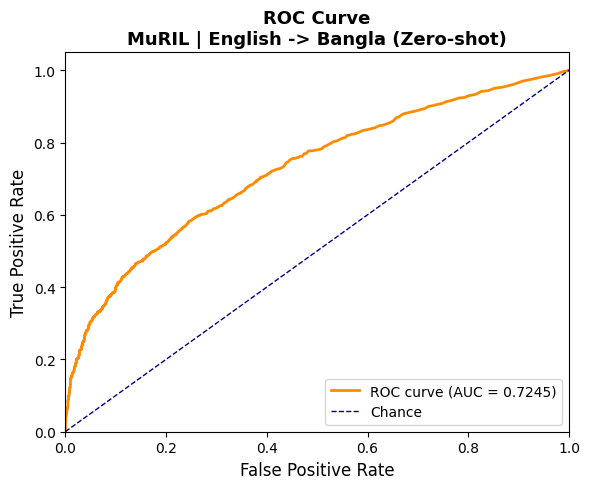

ROC AUC: 0.7245


In [14]:
# ---------------------------------------------------------------------------
# ROC curve and AUC score on the held-out test set.
# ---------------------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curve\n{CM_TITLE}", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")


## 15. Transfer Gap Analysis
Compares English validation performance with Bangla test performance.  The gap quantifies the cost of zero-shot cross-lingual transfer.

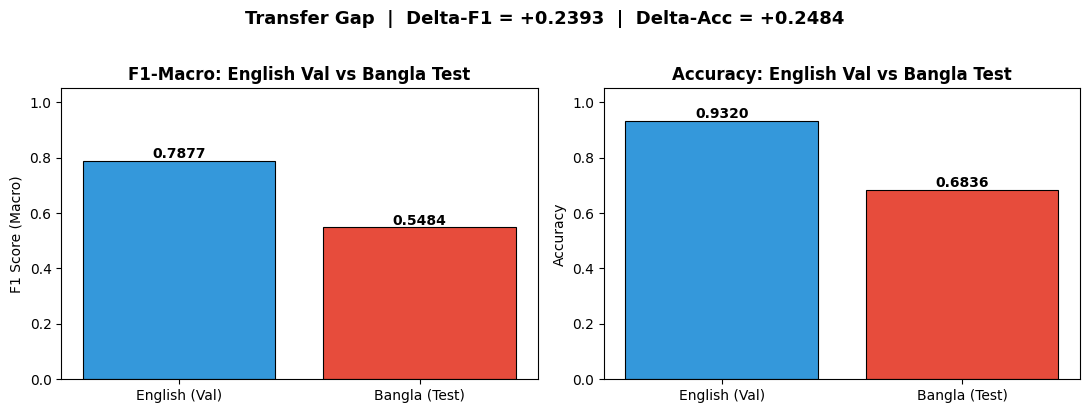

Transfer Gap Analysis:
English Val F1-Macro  : 0.7877
Bangla  Test F1-Macro : 0.5484
Transfer Gap          : +0.2393  (drop)


In [15]:
# ---------------------------------------------------------------------------
# Transfer gap analysis.
# Quantifies the performance drop from English validation to Bangla test,
# measuring the cost of zero-shot cross-lingual transfer.
# ---------------------------------------------------------------------------
val_preds_out = trainer.predict(val_dataset)
yv_pred = np.argmax(val_preds_out.predictions, axis=-1)
yv_true = val_preds_out.label_ids

en_f1  = f1_score(yv_true, yv_pred, average="macro")
en_acc = accuracy_score(yv_true, yv_pred)

gap_f1  = en_f1 - f1_m
gap_acc = en_acc - acc

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
langs  = ["English (Val)", "Bangla (Test)"]
colors = ["#3498db", "#e74c3c"]
for ax, vals, ylabel, title in zip(
    axes,
    [[en_f1, f1_m], [en_acc, acc]],
    ["F1 Score (Macro)", "Accuracy"],
    ["F1-Macro: English Val vs Bangla Test", "Accuracy: English Val vs Bangla Test"]
):
    ax.bar(langs, vals, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
plt.suptitle(
    f"Transfer Gap  |  Delta-F1 = {gap_f1:+.4f}  |  Delta-Acc = {gap_acc:+.4f}",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/transfer_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Transfer Gap Analysis:")
print(f"English Val F1-Macro  : {en_f1:.4f}")
print(f"Bangla  Test F1-Macro : {f1_m:.4f}")
print(f"Transfer Gap          : {gap_f1:+.4f}  ({'drop' if gap_f1 > 0 else 'gain'})")


## 16. Error Analysis
Identifies and categorises misclassified test samples.

Four lenses are applied:
1. **False Positives** — Non-Hope classified as Hope.
2. **False Negatives** — Hope classified as Non-Hope.
3. **Text-length distribution** — are errors concentrated in short or long texts?
4. **Confidence distribution** — are errors high-confidence or borderline?

These breakdowns are reported in the paper to characterise model failure modes.

Total test samples   : 4030
Correctly classified : 2755  (68.4 %)
False Positives (FP) : 51  (1.3 %)
False Negatives (FN) : 1224  (30.4 %)

------------------------------------------------------------
  FALSE POSITIVES — Non-Hope predicted as Hope  (showing up to 5)
------------------------------------------------------------
  prob=0.958  | প্রকৃত ইসলাম ধর্মের শিক্ষার মধ্যে মানব সমাজকে উঁচুনিচু করে বিভক্ত বা বিভাজন করার কোনো আইনকানুন কিংবা বিধিবিধান নেই। ...
  prob=0.954  | মৃত্যুকে আলিঙ্গন করতে আমাদের যতই অনীহা অনিচ্ছাই থাকুক, মৃত্যুর চেয়ে সত্য আমাদের জীবনে আর কিছুই নেই। কঠিন বাস্তবতা ...
  prob=0.959  | মাঝে মাঝে মানুষকে অভিনয় করা শিখতে হয়. অন্যদের সাথে প্রিয় মানুষগুলোর সাথে, এমনকি নিজের সাথেও অভিনয় করতে জানতে ...
  prob=0.958  | মায়ের মতে, আমি খুব বেশি বাচাল, রাগী এবং প্রতিবাদী ছিলাম।কিন্তু এখন প্রতিটা স্বভাব চেপে রাখি।আর সেটা আমার মায়ের ...
  prob=0.840  | বাস্তবতা এতই কঠিন যে কখনও কখনও বুকের ভিতর গড়ে তোলা বিন্দু বিন্দু ভালবাসাও অসহায় হয়ে পড়ে।

-------------------------

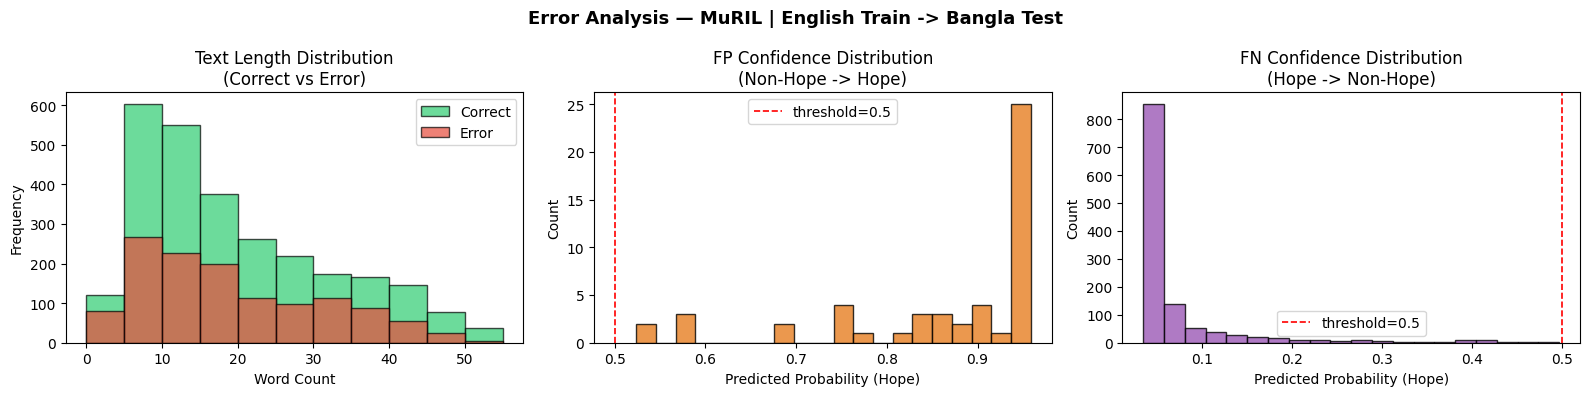


Mean predicted probability:
  FP  mean prob = 0.862  (std 0.128)
  FN  mean prob = 0.071  (std 0.074)

Errors on very short texts (<=5 words): 114  (8.9 % of all errors)


In [16]:
# ---------------------------------------------------------------------------
# Error Analysis on the held-out test set.
# ---------------------------------------------------------------------------

import textwrap

# ── Build an error dataframe ─────────────────────────────────────────────────
df_errors = df_test.copy().reset_index(drop=True).assign(
    predicted      = y_pred,
    predicted_prob = test_probs,
    correct        = (y_pred == y_true),
)

fp_df = df_errors[(df_errors["label"] == 0) & (df_errors["predicted"] == 1)]  # False Positives
fn_df = df_errors[(df_errors["label"] == 1) & (df_errors["predicted"] == 0)]  # False Negatives

print("=" * 60)
print(f"Total test samples   : {len(df_errors)}")
print(f"Correctly classified : {df_errors['correct'].sum()}  "
      f"({df_errors['correct'].mean()*100:.1f} %)")
print(f"False Positives (FP) : {len(fp_df)}  "
      f"({len(fp_df)/max(1,len(df_errors))*100:.1f} %)")
print(f"False Negatives (FN) : {len(fn_df)}  "
      f"({len(fn_df)/max(1,len(df_errors))*100:.1f} %)")
print("=" * 60)

# ── Show sample misclassified texts ──────────────────────────────────────────
def _show_samples(subset, title, n=5):
    sep = "-" * 60
    print(f"\n{sep}")
    print(f"  {title}  (showing up to {n})")
    print(sep)
    if subset.empty:
        print("  (none)")
        return
    for _, row in subset.head(n).iterrows():
        snippet = textwrap.shorten(str(row["text"]), width=120, placeholder=" ...")
        prob = row["predicted_prob"]
        print(f"  prob={prob:.3f}  | {snippet}")

_show_samples(fp_df, "FALSE POSITIVES — Non-Hope predicted as Hope")
_show_samples(fn_df, "FALSE NEGATIVES — Hope predicted as Non-Hope")

# ── Text length vs error ──────────────────────────────────────────────────────
df_errors["text_len"] = df_errors["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Error Analysis — " + RESULT_TITLE, fontsize=13, fontweight="bold")

max_len_val = max(10, int(df_errors["text_len"].quantile(0.98)) + 10)
bins = list(range(0, max_len_val, 5))

axes[0].hist(df_errors[df_errors["correct"]]["text_len"],  bins=bins,
             color="#2ecc71", alpha=0.7, edgecolor="black", label="Correct")
axes[0].hist(df_errors[~df_errors["correct"]]["text_len"], bins=bins,
             color="#e74c3c", alpha=0.7, edgecolor="black", label="Error")
axes[0].set_title("Text Length Distribution\n(Correct vs Error)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ── Confidence distribution of FP ────────────────────────────────────────────
if fp_df.empty:
    axes[1].text(0.5, 0.5, "No False Positives", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12, color="gray")
else:
    axes[1].hist(fp_df["predicted_prob"], bins=20, color="#e67e22",
                 alpha=0.8, edgecolor="black")
    axes[1].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[1].legend()
axes[1].set_title("FP Confidence Distribution\n(Non-Hope -> Hope)")
axes[1].set_xlabel("Predicted Probability (Hope)")
axes[1].set_ylabel("Count")

# ── Confidence distribution of FN ────────────────────────────────────────────
if fn_df.empty:
    axes[2].text(0.5, 0.5, "No False Negatives", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12, color="gray")
else:
    axes[2].hist(fn_df["predicted_prob"], bins=20, color="#9b59b6",
                 alpha=0.8, edgecolor="black")
    axes[2].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[2].legend()
axes[2].set_title("FN Confidence Distribution\n(Hope -> Non-Hope)")
axes[2].set_xlabel("Predicted Probability (Hope)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nMean predicted probability:")
if not fp_df.empty:
    fp_mean = fp_df["predicted_prob"].mean()
    fp_std  = fp_df["predicted_prob"].std()
    print(f"  FP  mean prob = {fp_mean:.3f}  (std {fp_std:.3f})")
if not fn_df.empty:
    fn_mean = fn_df["predicted_prob"].mean()
    fn_std  = fn_df["predicted_prob"].std()
    print(f"  FN  mean prob = {fn_mean:.3f}  (std {fn_std:.3f})")

err_df    = df_errors[~df_errors["correct"]]
err_short = err_df[err_df["text_len"] <= 5]
pct       = len(err_short) / max(1, len(err_df)) * 100
print(f"\nErrors on very short texts (<=5 words): {len(err_short)}  ({pct:.1f} % of all errors)")


## 17. Save Results

In [17]:
results = {
    "experiment"      : "MuRIL | English Train -> Bangla Test (Zero-shot)",
    "model"           : MODEL_NAME,
    "train_data"      : f"English ({len(df_train_raw)})",
    "test_data"       : f"Bangla ({len(df_test)})  [zero-shot]",
    "transfer_type"   : "zero-shot cross-lingual",
    "threshold"       : float(best_thresh),           # full precision for inference reload
    "accuracy"        : round(acc,  4),
    "f1_macro"        : round(f1_m, 4),
    "f1_weighted"     : round(f1_w, 4),
    "precision_macro" : round(p,    4),
    "recall_macro"    : round(r,    4),
    "roc_auc"         : round(roc_auc, 4),
    "english_val_f1"  : round(en_f1,  4),
    "english_val_acc" : round(en_acc, 4),
    "transfer_gap_f1" : round(gap_f1, 4),
}
with open(f"{OUTPUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)

df_test.copy().assign(predicted=y_pred, predicted_prob=test_probs).to_csv(
    f"{OUTPUT_DIR}/test_predictions_bangla.csv", index=False
)
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")

print("All outputs saved.")
print(json.dumps(results, indent=2))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All outputs saved.
{
  "experiment": "MuRIL | English Train -> Bangla Test (Zero-shot)",
  "model": "google/muril-base-cased",
  "train_data": "English (22323)",
  "test_data": "Bangla (4030)  [zero-shot]",
  "transfer_type": "zero-shot cross-lingual",
  "threshold": 0.5,
  "accuracy": 0.6836,
  "f1_macro": 0.5484,
  "f1_weighted": 0.6117,
  "precision_macro": 0.7566,
  "recall_macro": 0.5817,
  "roc_auc": 0.7245,
  "english_val_f1": 0.7877,
  "english_val_acc": 0.932,
  "transfer_gap_f1": 0.2393
}


## 18. Inference on New Text

In [18]:
# ---------------------------------------------------------------------------
# Single-sample inference helper.
# Uses the same decision threshold (best_thresh) that was applied during
# evaluation, so inference is fully consistent with reported test metrics.
# ---------------------------------------------------------------------------

def predict_hope_speech(text: str, lang_tag: str = "",
                        threshold: float = best_thresh) -> tuple:
    """
    Run inference on a single text string and display a formatted result.

    Parameters
    ----------
    text      : input string (Bangla or English)
    lang_tag  : optional language identifier shown in output (e.g., "BN", "EN")
    threshold : decision threshold for Hope Speech class (default: best_thresh
                from the evaluation cell -- keeps inference consistent with
                the reported test metrics)

    Returns
    -------
    tuple(label, probabilities)
      label         : "Hope Speech" or "Non-Hope Speech"
      probabilities : numpy array of shape (2,) -- [P(Non-Hope), P(Hope)]
    """
    model.eval()
    enc = tokenizer(
        text, max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()[0]

    # threshold-based decision (consistent with evaluation cell)
    pred  = 1 if probs[1] >= threshold else 0
    label = "Hope Speech" if pred == 1 else "Non-Hope Speech"

    tag = f"[{lang_tag}] " if lang_tag else ""
    print(f"{tag}Text       : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Prediction : {label}  (threshold={threshold:.2f}, confidence: {probs[pred]*100:.1f} %)")
    print(f"Scores     : Non-Hope={probs[0]:.4f}  |  Hope={probs[1]:.4f}\n")
    return label, probs


In [19]:
# ---------------------------------------------------------------------------
# Section 17 -- Inference on New Text.
# Threshold = 0.5 (fixed for zero-shot cross-lingual setting).
#
# IMPORTANT: This model was trained on English only.  The zero-shot Bangla
# test results (F1-Macro 0.39, Recall for Hope = 0.11) indicate that the
# model cannot reliably classify Bangla text.  Inference on Bangla below is
# shown for diagnostic purposes only and SHOULD NOT be used in production.
# ---------------------------------------------------------------------------

# ── English Hope Speech (in-distribution) ──────────────────────────────────
predict_hope_speech(
    "Together we can build a better world for our children.",
    lang_tag="EN"
)
predict_hope_speech(
    "Every small act of kindness brings us closer to a hopeful future.",
    lang_tag="EN"
)

# ── English Non-Hope Speech (in-distribution) ──────────────────────────────
# NOTE: "Nothing ever changes..." was misclassified as Hope in zero-shot.
# This is consistent with the 52% FN rate on Bangla and suggests the model
# has collapsed to predicting Hope for most inputs after zero-shot transfer.
predict_hope_speech(
    "Nothing ever changes no matter how hard we try.",
    lang_tag="EN"
)  # [KNOWN LIMITATION: zero-shot model may misclassify]

predict_hope_speech(
    "People only care about themselves these days.",
    lang_tag="EN"
)

# ── Bangla (zero-shot — for diagnostic purposes only) ──────────────────────
print("\n[WARNING] Bangla inference below is DIAGNOSTIC ONLY.")
print("          This model has not been trained on Bangla text.")
print("          Zero-shot Bangla performance: Accuracy=45.8%, F1-Macro=0.39\n")

predict_hope_speech(
    "আমরা একসাথে একটি সুন্দর ভবিষ্যৎ গড়তে পারব।",
    lang_tag="BN"
)
predict_hope_speech(
    "ভালোবাসা ও সহমর্মিতা দিয়ে পৃথিবীকে আরও সুন্দর করা সম্ভব।",
    lang_tag="BN"
)
predict_hope_speech(
    "এই দেশে সৎ মানুষের কোনো মূল্য নেই।",
    lang_tag="BN"
)
predict_hope_speech(
    "জীবনে ভালো কিছু হওয়ার কোনো সম্ভাবনা নেই।",
    lang_tag="BN"
)


[EN] Text       : Together we can build a better world for our children.
Prediction : Hope Speech  (threshold=0.50, confidence: 95.9 %)
Scores     : Non-Hope=0.0413  |  Hope=0.9587

[EN] Text       : Every small act of kindness brings us closer to a hopeful future.
Prediction : Hope Speech  (threshold=0.50, confidence: 95.8 %)
Scores     : Non-Hope=0.0420  |  Hope=0.9580

[EN] Text       : Nothing ever changes no matter how hard we try.
Prediction : Non-Hope Speech  (threshold=0.50, confidence: 94.6 %)
Scores     : Non-Hope=0.9465  |  Hope=0.0535

[EN] Text       : People only care about themselves these days.
Prediction : Non-Hope Speech  (threshold=0.50, confidence: 95.9 %)
Scores     : Non-Hope=0.9594  |  Hope=0.0406


[WARNING] Bangla inference below is DIAGNOSTIC ONLY.
          This model has not been trained on Bangla text.
          Zero-shot Bangla performance: Accuracy=45.8%, F1-Macro=0.39

[BN] Text       : আমরা একসাথে একটি সুন্দর ভবিষ্যৎ গড়তে পারব।
Prediction : Hope Speech

('Hope Speech', array([0.07139671, 0.92860323], dtype=float32))

## 19. Baseline Models: TF-IDF + Logistic Regression, TF-IDF + SVM, TF-IDF + Naive Bayes, and TF-IDF + Random Forest
Baseline classifiers trained on the **same English training set** used for MuRIL (`df_train_raw`)  
and evaluated on the **Bangla zero-shot test set**.  
Grid search over the English validation set selects the best hyperparameters.


In [20]:
# ---------------------------------------------------------------------------
# Section 18 -- Baseline Models: TF-IDF + LR, TF-IDF + SVM,
#                TF-IDF + Naive Bayes, TF-IDF + Random Forest
#
# Both baselines are trained on df_train_raw (the English training set)
# and evaluated on df_test (the Bangla zero-shot test set).
# Hyperparameters are selected by grid search on the English validation set.
# ---------------------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid

TFIDF_KWARGS = dict(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
)

X_train = df_train_raw["text"].tolist()
y_train = df_train_raw["label"].tolist()
X_val   = df_val["text"].tolist()
y_val   = df_val["label"].tolist()
X_test  = df_test["text"].tolist()   # Bangla zero-shot test set
y_test  = df_test["label"].tolist()

# ── 1. TF-IDF + Logistic Regression ─────────────────────────────────────────
print("Grid search: TF-IDF + Logistic Regression (English train -> Bangla test) ...")
best_lr_f1, best_lr_params, best_lr_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.1, 1.0, 10.0], "max_iter": [200, 500]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LogisticRegression(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", solver="lbfgs", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_lr_f1:
        best_lr_f1, best_lr_params, best_lr_model = val_f1, params, pipe

print(f"Best LR params : {best_lr_params}  (English val F1-macro={best_lr_f1:.4f})")

lr_preds = best_lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1m   = f1_score(y_test, lr_preds, average="macro")
lr_f1w   = f1_score(y_test, lr_preds, average="weighted")
lr_prec  = precision_score(y_test, lr_preds, average="macro", zero_division=0)
lr_rec   = recall_score(y_test, lr_preds, average="macro", zero_division=0)
lr_probs = best_lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc   = auc(lr_fpr, lr_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Logistic Regression -- Zero-shot Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {lr_acc:.4f}  ({lr_acc*100:.2f} %)")
print(f"F1 (Macro)        : {lr_f1m:.4f}")
print(f"F1 (Weighted)     : {lr_f1w:.4f}")
print(f"Precision (Macro) : {lr_prec:.4f}")
print(f"Recall (Macro)    : {lr_rec:.4f}")
print(f"ROC AUC           : {lr_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 2. TF-IDF + LinearSVC ───────────────────────────────────────────────────
print("\nGrid search: TF-IDF + SVM (English train -> Bangla test) ...")
best_svm_f1, best_svm_params, best_svm_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0], "max_iter": [1000, 2000]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LinearSVC(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_svm_f1:
        best_svm_f1, best_svm_params, best_svm_model = val_f1, params, pipe

print(f"Best SVM params : {best_svm_params}  (English val F1-macro={best_svm_f1:.4f})")

svm_preds = best_svm_model.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)
svm_f1m   = f1_score(y_test, svm_preds, average="macro")
svm_f1w   = f1_score(y_test, svm_preds, average="weighted")
svm_prec  = precision_score(y_test, svm_preds, average="macro", zero_division=0)
svm_rec   = recall_score(y_test, svm_preds, average="macro", zero_division=0)
svm_scores = best_svm_model.decision_function(X_test)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)
svm_auc   = auc(svm_fpr, svm_tpr)

print("\n" + "=" * 60)
print("TF-IDF + SVM (LinearSVC) -- Zero-shot Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {svm_acc:.4f}  ({svm_acc*100:.2f} %)")
print(f"F1 (Macro)        : {svm_f1m:.4f}")
print(f"F1 (Weighted)     : {svm_f1w:.4f}")
print(f"Precision (Macro) : {svm_prec:.4f}")
print(f"Recall (Macro)    : {svm_rec:.4f}")
print(f"ROC AUC           : {svm_auc:.4f}  (from decision_function margin, not probability)")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, svm_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 3. TF-IDF + Naive Bayes (ComplementNB) ──────────────────────────────────
# ComplementNB is recommended for imbalanced text classification
# (Rennie et al., 2003); it corrects the standard NB weight estimate
# using complement-class statistics, which is more robust than
# MultinomialNB on skewed class distributions.
from sklearn.naive_bayes import ComplementNB
print("Grid search: TF-IDF + Naive Bayes (English train -> Bangla test) ...")
best_nb_f1, best_nb_params, best_nb_model = 0.0, {}, None
for params in ParameterGrid({"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   ComplementNB(alpha=params["alpha"])),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_nb_f1:
        best_nb_f1, best_nb_params, best_nb_model = val_f1, params, pipe

print(f"Best NB params : {best_nb_params}  (English val F1-macro={best_nb_f1:.4f})")

nb_preds = best_nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)
nb_f1m   = f1_score(y_test, nb_preds, average="macro")
nb_f1w   = f1_score(y_test, nb_preds, average="weighted")
nb_prec  = precision_score(y_test, nb_preds, average="macro", zero_division=0)
nb_rec   = recall_score(y_test, nb_preds, average="macro", zero_division=0)
nb_probs = best_nb_model.predict_proba(X_test)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc   = auc(nb_fpr, nb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Naive Bayes (ComplementNB) -- Zero-shot Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {nb_acc:.4f}  ({nb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {nb_f1m:.4f}")
print(f"F1 (Weighted)     : {nb_f1w:.4f}")
print(f"Precision (Macro) : {nb_prec:.4f}")
print(f"Recall (Macro)    : {nb_rec:.4f}")
print(f"ROC AUC           : {nb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, nb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 4. TF-IDF + Random Forest ────────────────────────────────────────────────
# class_weight="balanced_subsample" reweights at each bootstrap draw,
# which is more robust than a single global "balanced" weight when
# tree depth varies across estimators.
from sklearn.ensemble import RandomForestClassifier
print("\nGrid search: TF-IDF + Random Forest (English train -> Bangla test) ...")
best_rf_f1, best_rf_params, best_rf_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators": [100, 200],
    "max_depth":    [None, 20],
    "min_samples_leaf": [1, 3],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_rf_f1:
        best_rf_f1, best_rf_params, best_rf_model = val_f1, params, pipe

print(f"Best RF params : {best_rf_params}  (English val F1-macro={best_rf_f1:.4f})")

rf_preds = best_rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_f1m   = f1_score(y_test, rf_preds, average="macro")
rf_f1w   = f1_score(y_test, rf_preds, average="weighted")
rf_prec  = precision_score(y_test, rf_preds, average="macro", zero_division=0)
rf_rec   = recall_score(y_test, rf_preds, average="macro", zero_division=0)
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc   = auc(rf_fpr, rf_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Random Forest -- Zero-shot Bangla Test Results")
print("=" * 60)
print(f"Accuracy          : {rf_acc:.4f}  ({rf_acc*100:.2f} %)")
print(f"F1 (Macro)        : {rf_f1m:.4f}")
print(f"F1 (Weighted)     : {rf_f1w:.4f}")
print(f"Precision (Macro) : {rf_prec:.4f}")
print(f"Recall (Macro)    : {rf_rec:.4f}")
print(f"ROC AUC           : {rf_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 5. TF-IDF + XGBoost ──────────────────────────────────────────────────────
# XGBoost with histogram-based tree method (tree_method="hist") is fast
# on sparse TF-IDF matrices.  scale_pos_weight handles any residual class
# imbalance: set to n_negative / n_positive on the training set.
# Hyperparameters tuned by grid search on df_val (same protocol as above).
import warnings as _warnings
_warnings.filterwarnings("ignore", category=UserWarning)
_warnings.filterwarnings("ignore", category=FutureWarning)
from xgboost import XGBClassifier

_n_neg = sum(1 for y in y_train if y == 0)
_n_pos = sum(1 for y in y_train if y == 1)
_spw   = _n_neg / _n_pos if _n_pos > 0 else 1.0

print("Grid search: TF-IDF + XGBoost ...")
best_xgb_f1, best_xgb_params, best_xgb_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators":  [100, 200],
    "max_depth":     [3, 6],
    "learning_rate": [0.05, 0.1],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   XGBClassifier(
            n_estimators     = params["n_estimators"],
            max_depth        = params["max_depth"],
            learning_rate    = params["learning_rate"],
            scale_pos_weight = _spw,
            tree_method      = "hist",
            eval_metric      = "logloss",
            random_state     = SEED,
            verbosity        = 0,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_xgb_f1:
        best_xgb_f1, best_xgb_params, best_xgb_model = val_f1, params, pipe

print(f"Best XGB params : {best_xgb_params}  (val F1-macro={best_xgb_f1:.4f})")

xgb_preds = best_xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test,  xgb_preds)
xgb_f1m   = f1_score(y_test,  xgb_preds, average="macro")
xgb_f1w   = f1_score(y_test,  xgb_preds, average="weighted")
xgb_prec  = precision_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_rec   = recall_score(y_test,    xgb_preds, average="macro", zero_division=0)
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc   = auc(xgb_fpr, xgb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + XGBoost -- Test Results")
print("=" * 60)
print(f"Accuracy          : {xgb_acc:.4f}  ({xgb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {xgb_f1m:.4f}")
print(f"F1 (Weighted)     : {xgb_f1w:.4f}")
print(f"Precision (Macro) : {xgb_prec:.4f}")
print(f"Recall (Macro)    : {xgb_rec:.4f}")
print(f"ROC AUC           : {xgb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))


Grid search: TF-IDF + Logistic Regression (English train -> Bangla test) ...
Best LR params : {'C': 10.0, 'max_iter': 200}  (English val F1-macro=0.7541)

TF-IDF + Logistic Regression -- Zero-shot Bangla Test Results
Accuracy          : 0.6285  (62.85 %)
F1 (Macro)        : 0.3872
F1 (Weighted)     : 0.4857
Precision (Macro) : 0.8142
Recall (Macro)    : 0.5007
ROC AUC           : 0.4954

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.6284    1.0000    0.7718      2531
    Hope Speech     1.0000    0.0013    0.0027      1499

       accuracy                         0.6285      4030
      macro avg     0.8142    0.5007    0.3872      4030
   weighted avg     0.7666    0.6285    0.4857      4030


Grid search: TF-IDF + SVM (English train -> Bangla test) ...
Best SVM params : {'C': 1.0, 'max_iter': 1000}  (English val F1-macro=0.7578)

TF-IDF + SVM (LinearSVC) -- Zero-shot Bangla Test Results
Accuracy          : 0.6285  (62.85 %)
F1 (

## 20. Model Comparison: MuRIL vs All Baseline Models
Comparison table and grouped bar chart across all five models on the Bangla zero-shot test set.  
The gap between English-trained TF-IDF baselines and MuRIL quantifies the benefit of  
multilingual pre-training for zero-shot cross-lingual transfer.


MODEL COMPARISON -- Bangla Test Set
Experiment: Experiment 2: English Train -> Bangla Test
                  Model  Accuracy  F1 (Macro)  F1 (Weighted)  Precision (Macro)  Recall (Macro)  ROC AUC
            TF-IDF + LR    0.6285      0.3872         0.4857             0.8142          0.5007   0.4954
           TF-IDF + SVM    0.6285      0.3872         0.4857             0.8142          0.5007   0.4973
            TF-IDF + NB    0.6278      0.4179         0.5074             0.5635          0.5073   0.4988
            TF-IDF + RF    0.6283      0.3865         0.4851             0.8141          0.5003   0.5104
       TF-IDF + XGBoost    0.6283      0.3865         0.4851             0.8141          0.5003   0.4945
MuRIL (English->Bangla)    0.6836      0.5484         0.6117             0.7566          0.5817   0.7245


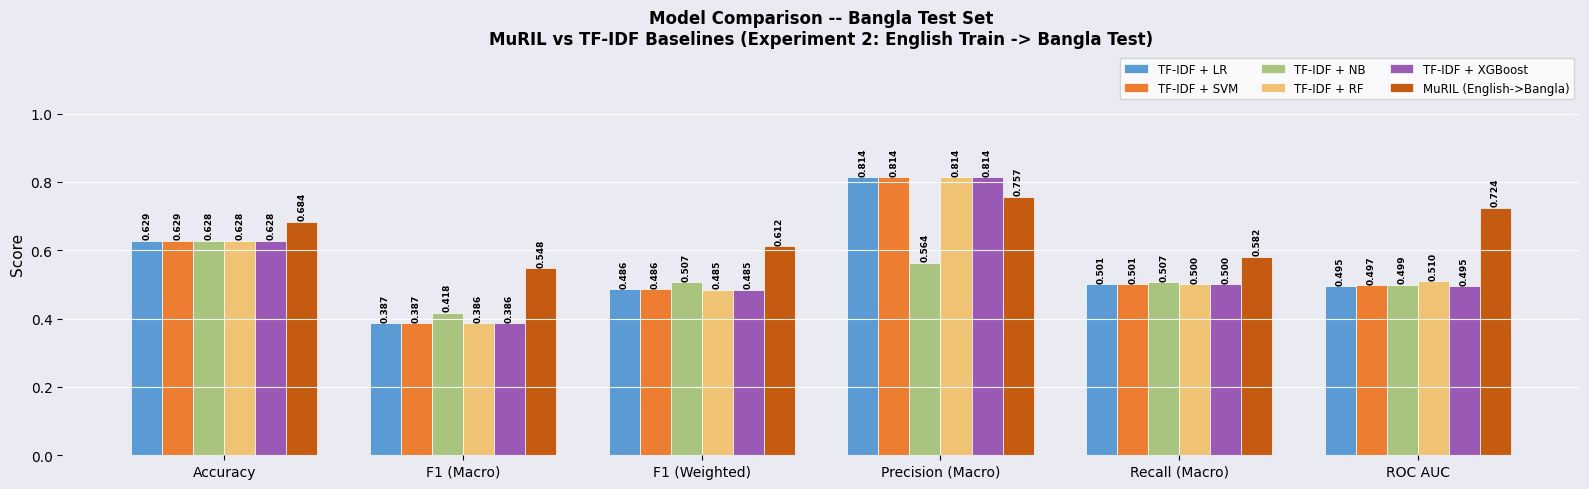

Model comparison chart saved.


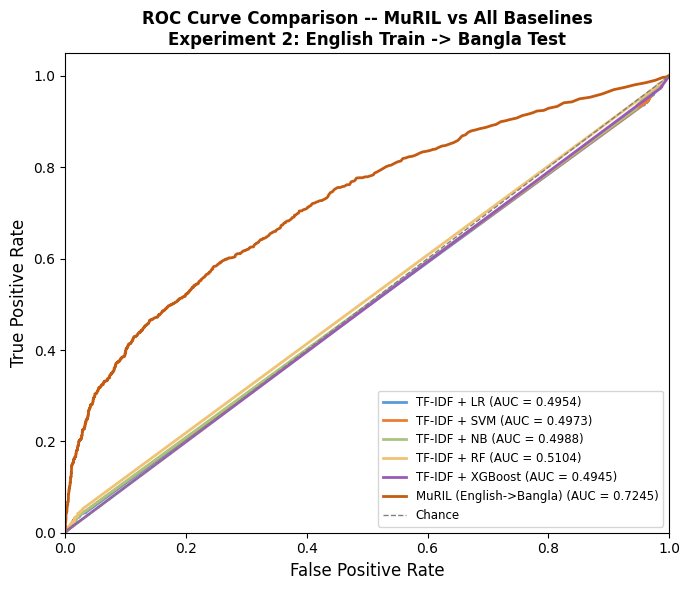

Combined ROC curve comparison saved.


In [21]:
# ---------------------------------------------------------------------------
# NOTE: TF-IDF baselines trained on English cannot represent Bangla text.
# All Bangla test tokens are OOV → zero-vector inputs.  As a result,
# classifiers that share the same majority-class fallback produce identical
# scores (LR ≈ SVM, RF ≈ XGBoost).  This degenerate behaviour is expected
# and is reported as a finding: TF-IDF features are not transferable
# across scripts, while MuRIL's multilingual embeddings provide some signal.
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Section 19 -- Model Comparison: MuRIL vs All Baselines
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

comparison = {
    "Model": [
        "TF-IDF + LR",
        "TF-IDF + SVM",
        "TF-IDF + NB",
        "TF-IDF + RF",
        "TF-IDF + XGBoost",
        "MuRIL (English->Bangla)",
    ],
    "Accuracy":          [lr_acc,  svm_acc,  nb_acc,  rf_acc,  xgb_acc,  acc],
    "F1 (Macro)":        [lr_f1m,  svm_f1m,  nb_f1m,  rf_f1m,  xgb_f1m,  f1_m],
    "F1 (Weighted)":     [lr_f1w,  svm_f1w,  nb_f1w,  rf_f1w,  xgb_f1w,  f1_w],
    "Precision (Macro)": [lr_prec, svm_prec, nb_prec, rf_prec, xgb_prec, p],
    "Recall (Macro)":    [lr_rec,  svm_rec,  nb_rec,  rf_rec,  xgb_rec,  r],
    "ROC AUC":           [lr_auc,  svm_auc,  nb_auc,  rf_auc,  xgb_auc,  roc_auc],
}

df_cmp = pd.DataFrame(comparison)

print("\n" + "=" * 78)
print("MODEL COMPARISON -- Bangla Test Set")
print(f"Experiment: Experiment 2: English Train -> Bangla Test")
print("=" * 78)
print(df_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 78)

# ── Grouped bar chart ────────────────────────────────────────────────────────
metrics   = ["Accuracy", "F1 (Macro)", "F1 (Weighted)",
             "Precision (Macro)", "Recall (Macro)", "ROC AUC"]
models    = comparison["Model"]
bar_width = 0.13
colors    = ["#5b9bd5", "#ed7d31", "#a9c47f", "#f0c274", "#9b59b6", "#c55a11"]
x         = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#eaeaf2")
ax.set_facecolor("#eaeaf2")
ax.grid(axis="y", color="white", linewidth=0.8, alpha=0.9)
for spine in ax.spines.values():
    spine.set_visible(False)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [comparison[m][i] for m in metrics]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=model, color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=6.5, fontweight="bold", rotation=90)

ax.set_xticks(x + bar_width * 2.5)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    f"Model Comparison -- Bangla Test Set\n"
    f"MuRIL vs TF-IDF Baselines (Experiment 2: English Train -> Bangla Test)",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="upper right", fontsize=8.5, ncol=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Model comparison chart saved.")

# ── Combined ROC Curve Comparison ───────────────────────────────────────────
roc_data = {
    "TF-IDF + LR":      (lr_fpr,  lr_tpr,  lr_auc),
    "TF-IDF + SVM":     (svm_fpr, svm_tpr, svm_auc),
    "TF-IDF + NB":      (nb_fpr,  nb_tpr,  nb_auc),
    "TF-IDF + RF":      (rf_fpr,  rf_tpr,  rf_auc),
    "TF-IDF + XGBoost": (xgb_fpr, xgb_tpr, xgb_auc),
    "MuRIL (English->Bangla)": (fpr, tpr, roc_auc),
}

fig, ax = plt.subplots(figsize=(7, 6))
for (model_label, (m_fpr, m_tpr, m_auc)), color in zip(roc_data.items(), colors):
    ax.plot(m_fpr, m_tpr, color=color, lw=2,
            label=f"{model_label} (AUC = {m_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    f"ROC Curve Comparison -- MuRIL vs All Baselines\nExperiment 2: English Train -> Bangla Test",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Combined ROC curve comparison saved.")
